# **FASE 2.1 – Comparativos Diversos**

Neste segundo notebook, daremos continuidade ao trabalho iniciado na etapa de pré-processamento, onde realizamos a leitura e unificação das bases do ENEM de 2018 a 2023, aplicamos o filtro para as cidades da área de abrangência do IFNMG, removemos colunas desnecessárias, eliminamos registros de candidatos ausentes, renomeamos variáveis do questionário para facilitar a compreensão, tratamos duplicidades e inconsistências de codificação, além de compilar os dados apenas do estado de Minas Gerais e converter variáveis categóricas em ordinais. Assim, a partir dessa base já estruturada e padronizada, avançaremos agora para a etapa de aplicação de métodos estatísticos, buscando extrair interpretações relevantes sobre os candidatos e seus contextos.

Importando as bibliotecas que serão utilizadas.

In [4]:
import os
import pandas as pd
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler

### **Realizando a leitura da base de área de abrangencia do IFNMG**

In [5]:
df_final = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\ENEM_RENOMEADO.parquet", engine="fastparquet")
df_final

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,TP_LOCALIZACAO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,1.0,Rio Pardo de Minas,1.0,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,1.0,São Francisco,1.0,...,A,A,A,B,B,A,D,A,A,B
2,2018,2,M,0.0,3,1,2,1.0,Montalvânia,1.0,...,A,A,A,B,A,A,C,A,B,B
3,2018,3,F,0.0,1,1,2,1.0,Teófilo Otoni,1.0,...,B,A,A,B,A,B,E,A,B,B
4,2018,3,M,0.0,1,1,1,1.0,Januária,2.0,...,A,A,A,C,B,A,D,B,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59749,2023,3,M,0.0,3,1,2,1.0,Pedra Azul,1.0,...,A,A,A,A,A,A,B,A,A,A
59750,2023,3,F,1.0,3,1,2,1.0,Montes Claros,1.0,...,B,A,B,B,A,B,E,A,C,B
59751,2023,4,M,1.0,1,1,2,NaN,Teófilo Otoni,1.0,...,B,A,A,A,A,A,D,A,A,B
59752,2023,2,M,1.0,3,1,2,1.0,Montes Claros,1.0,...,B,A,B,B,B,A,E,B,C,B


### **Realizando a leitura da base de MG**

In [6]:
df_mg = pd.read_parquet(r"C:\Users\fernanda.leal\Documents\FERNANDA\TCC\DESENVOLVIMENTO\BASES\processed\MG.parquet", engine="fastparquet")
df_mg

,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_ESTADO_CIVIL,TP_COR_RACA,TP_NACIONALIDADE,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,...,MICROONDAS,LAVA_LOUCA,ASPIRADOR,TV,DVD,TV_ASSINATURA,CELULAR,TELEFONE_FIXO,COMPUTADOR,INTERNET
0,2018,3,M,0.0,0,1,2,2,1.0,Rio Pardo de Minas,...,A,A,A,B,B,A,D,A,A,A
1,2018,2,F,0.0,3,1,2,2,1.0,São Francisco,...,A,A,A,B,B,A,D,A,A,B
2,2018,11,M,0.0,3,1,2,2,3.0,Boa Esperança,...,B,A,A,A,A,A,B,B,B,B
3,2018,12,F,0.0,3,1,2,2,3.0,Vespasiano,...,A,A,A,B,A,A,B,A,A,A
4,2018,2,M,0.0,3,1,2,2,1.0,Montalvânia,...,A,A,A,B,A,A,C,A,B,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
517822,2023,4,M,1.0,2,3,2,2,NaN,Rio Vermelho,...,A,A,A,A,A,A,C,A,A,B
517823,2023,2,F,1.0,1,1,2,2,1.0,Juiz de Fora,...,A,A,A,C,A,A,D,A,A,B
517824,2023,2,M,1.0,1,1,2,2,1.0,Pouso Alegre,...,A,A,B,B,A,B,E,A,D,B
517825,2023,2,F,1.0,3,1,2,2,1.0,Ipaba,...,B,A,A,B,A,A,D,A,B,B


### **1. Gráfico da quantidade de participantes por ano IFNMG e MG em %.**

   NU_ANO  Participantes IFNMG  Participantes MG  IFNMG % (base 2018=100)  \
0    2018                17893            137963               100.000000   
1    2019                14956            108173                83.585760   
2    2020                 6339             71614                35.427262   
3    2021                 6664             64236                37.243615   
4    2022                 7128             68869                39.836808   
5    2023                 6774             66972                37.858380   

   MG % (base 2018=100)  
0            100.000000  
1             78.407254  
2             51.908120  
3             46.560310  
4             49.918456  
5             48.543450  


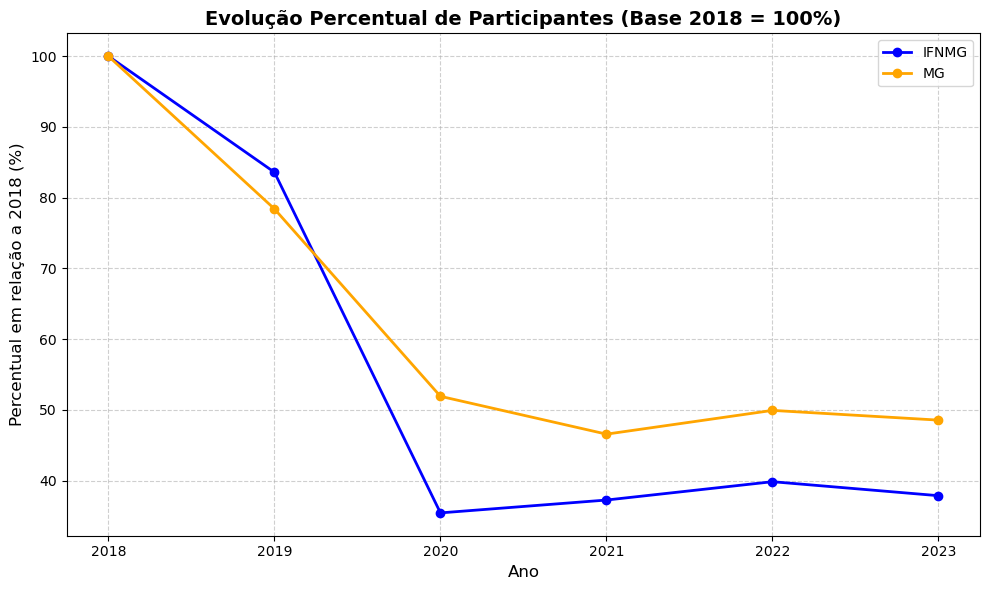

In [7]:
# Agrupar por ano — IFNMG
qtd_ifnmg = df_final.groupby("NU_ANO").size().reset_index(name="Participantes IFNMG")

# Agrupar por ano — MG
qtd_mg = df_mg.groupby("NU_ANO").size().reset_index(name="Participantes MG")

# Juntar os dois dataframes
qtd_total = pd.merge(qtd_ifnmg, qtd_mg, on="NU_ANO", how="inner")

# Calcular o percentual tomando 2018 como 100%
ano_base = 2018
base_ifnmg = qtd_total.loc[qtd_total["NU_ANO"] == ano_base, "Participantes IFNMG"].values[0]
base_mg = qtd_total.loc[qtd_total["NU_ANO"] == ano_base, "Participantes MG"].values[0]

qtd_total["IFNMG % (base 2018=100)"] = (qtd_total["Participantes IFNMG"] / base_ifnmg) * 100
qtd_total["MG % (base 2018=100)"] = (qtd_total["Participantes MG"] / base_mg) * 100

# Exibir tabela resumida
print(qtd_total)

# ---------- GRÁFICO ----------
plt.figure(figsize=(10,6))
plt.plot(qtd_total["NU_ANO"], qtd_total["IFNMG % (base 2018=100)"], 
         marker='o', color='blue', linewidth=2, label="IFNMG")
plt.plot(qtd_total["NU_ANO"], qtd_total["MG % (base 2018=100)"], 
         marker='o', color='orange', linewidth=2, label="MG")

plt.title("Evolução Percentual de Participantes (Base 2018 = 100%)", fontsize=14, fontweight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Percentual em relação a 2018 (%)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### **2. Comparativo entre as escolas do IFNMG e MG**

🔹 Comparativo de Tipos de Escola (IFNMG x MG):


,Qtd IFNMG,% IFNMG,Qtd MG,% MG
TP_ESCOLA_PAD,,,,
Não Informado,736,1.23,5748,1.11
Pública,52538,87.92,418193,80.76
Privada,6466,10.82,92230,17.81
Exterior,14,0.02,1656,0.32


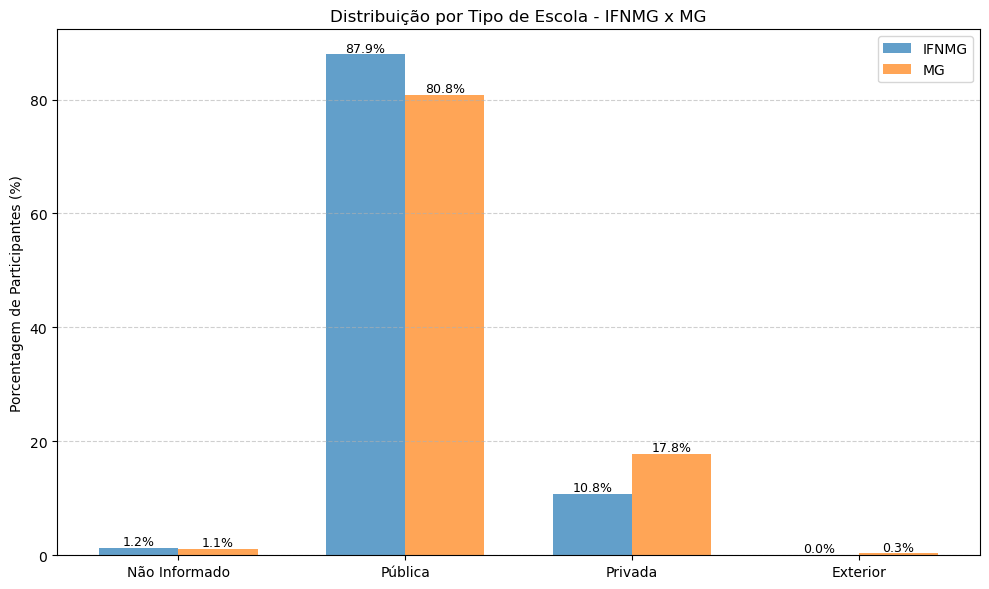

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1️⃣ Função de padronização correta por ano
# ============================================================

def padronizar_tp_escola(row):
    ano = row["NU_ANO"]
    valor = row["TP_ESCOLA"]

    if pd.isna(valor):
        return "Não Informado"

    # 2018
    if ano == 2018:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            4: "Privada",
            3: "Exterior"
        }

    # 2019 e 2020
    elif ano in [2019, 2020]:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            3: "Privada",
            4: "Exterior"
        }

    # 2021+
    elif ano in [2021, 2022, 2023]:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            3: "Privada"
        }

    else:
        return "Não Informado"

    return mapa.get(valor, "Não Informado")


# ============================================================
# 2️⃣ Criar variável padronizada (SEM alterar original)
# ============================================================

df_final["TP_ESCOLA_PAD"] = df_final.apply(padronizar_tp_escola, axis=1)
df_mg["TP_ESCOLA_PAD"] = df_mg.apply(padronizar_tp_escola, axis=1)


# Ordem fixa das categorias
ordem = ["Não Informado", "Pública", "Privada", "Exterior"]


# ============================================================
# 3️⃣ IFNMG
# ============================================================

qtd_ifnmg = (
    df_final["TP_ESCOLA_PAD"]
    .value_counts()
    .reindex(ordem, fill_value=0)
)

porc_ifnmg = (qtd_ifnmg / qtd_ifnmg.sum() * 100).round(2)


# ============================================================
# 4️⃣ MG
# ============================================================

qtd_mg = (
    df_mg["TP_ESCOLA_PAD"]
    .value_counts()
    .reindex(ordem, fill_value=0)
)

porc_mg = (qtd_mg / qtd_mg.sum() * 100).round(2)


# ============================================================
# 5️⃣ Tabela Comparativa
# ============================================================

tabela_escola = pd.DataFrame({
    "Qtd IFNMG": qtd_ifnmg,
    "% IFNMG": porc_ifnmg,
    "Qtd MG": qtd_mg,
    "% MG": porc_mg
})

print("🔹 Comparativo de Tipos de Escola (IFNMG x MG):")
display(tabela_escola)


# ============================================================
# 6️⃣ Gráfico
# ============================================================

plt.figure(figsize=(10,6))
x = range(len(ordem))
largura = 0.35

plt.bar([i - largura/2 for i in x], porc_ifnmg, width=largura, label='IFNMG', alpha=0.7)
plt.bar([i + largura/2 for i in x], porc_mg, width=largura, label='MG', alpha=0.7)

plt.xticks(x, ordem)
plt.ylabel("Porcentagem de Participantes (%)")
plt.title("Distribuição por Tipo de Escola - IFNMG x MG")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Rótulos
for i, valor in enumerate(porc_ifnmg):
    plt.text(i - largura/2, valor + 0.5, f"{valor:.1f}%", ha='center', fontsize=9)

for i, valor in enumerate(porc_mg):
    plt.text(i + largura/2, valor + 0.5, f"{valor:.1f}%", ha='center', fontsize=9)

plt.show()


### **3. Olhando por sexo no decorrer do anos - IFNMG**

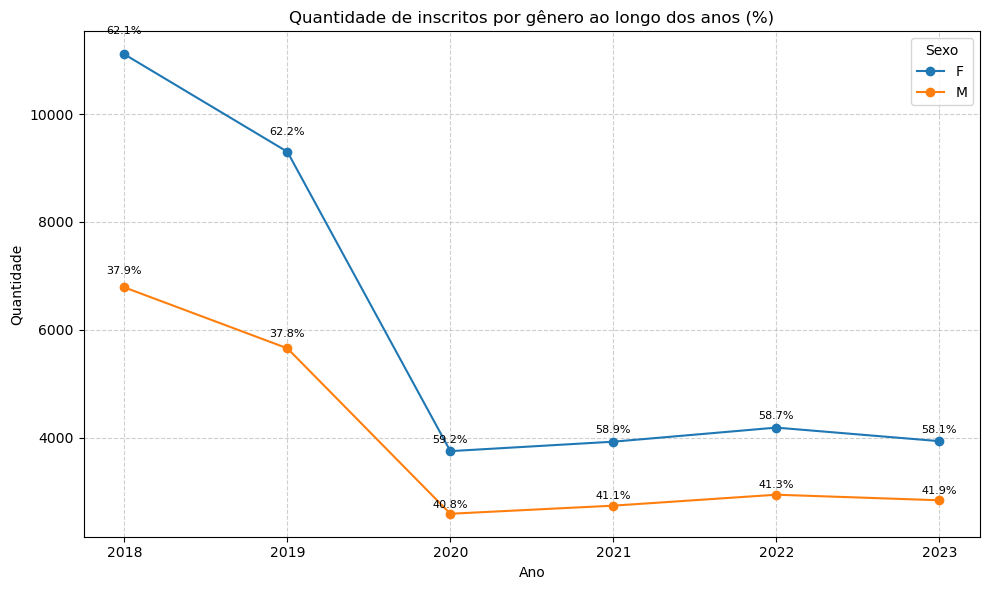

In [11]:
# Agrupar por ano e sexo (F, M)
df_grouped = df_final.groupby(["NU_ANO", "TP_SEXO"]).size().reset_index(name="Quantidade")

# Calcular o total de inscritos por ano
totais_ano = df_grouped.groupby("NU_ANO")["Quantidade"].transform("sum")

# Calcular percentual
df_grouped["Percentual"] = (df_grouped["Quantidade"] / totais_ano) * 100

# Plot
plt.figure(figsize=(10,6))
for sexo in df_grouped["TP_SEXO"].unique():
    subset = df_grouped[df_grouped["TP_SEXO"] == sexo]
    plt.plot(subset["NU_ANO"], subset["Quantidade"], marker="o", label=sexo)
    # Adicionar porcentagem logo acima dos pontos
    for x, y, p in zip(subset["NU_ANO"], subset["Quantidade"], subset["Percentual"]):
        plt.text(x, y + (y * 0.03), f"{p:.1f}%", ha="center", va="bottom", fontsize=8)

plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Quantidade de inscritos por gênero ao longo dos anos (%)")
plt.legend(title="Sexo")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### **4. Olhando por sexo no decorrer do anos - MG**

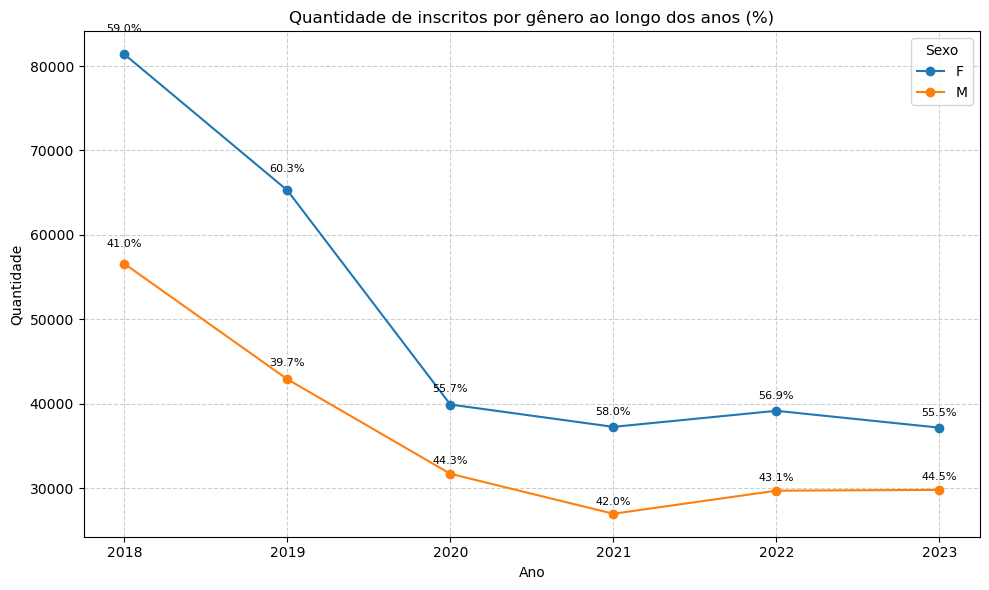

In [13]:
# Agrupar por ano e sexo (F, M)
df_grouped = df_mg.groupby(["NU_ANO", "TP_SEXO"]).size().reset_index(name="Quantidade")

# Calcular o total de inscritos por ano
totais_ano = df_grouped.groupby("NU_ANO")["Quantidade"].transform("sum")

# Calcular percentual
df_grouped["Percentual"] = (df_grouped["Quantidade"] / totais_ano) * 100

# Plot
plt.figure(figsize=(10,6))
for sexo in df_grouped["TP_SEXO"].unique():
    subset = df_grouped[df_grouped["TP_SEXO"] == sexo]
    plt.plot(subset["NU_ANO"], subset["Quantidade"], marker="o", label=sexo)
    # Adicionar porcentagem ajustada próximo ao ponto
    for x, y, p in zip(subset["NU_ANO"], subset["Quantidade"], subset["Percentual"]):
        plt.text(x, y + (y * 0.03), f"{p:.1f}%", ha="center", va="bottom", fontsize=8)

plt.xlabel("Ano")
plt.ylabel("Quantidade")
plt.title("Quantidade de inscritos por gênero ao longo dos anos (%)")
plt.legend(title="Sexo")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

,Qtd IFNMG,% IFNMG,Qtd MG,% MG
TP_ESTADO_CIVIL_MAP,,,,
Solteiro(a),18430,31.00,141708,27.52
Casado(a)/Companheiro(a),40490,68.10,365757,71.03
Divorciado(a)/Separado(a),292,0.49,4480,0.87
Viúvo(a),245,0.41,3001,0.58


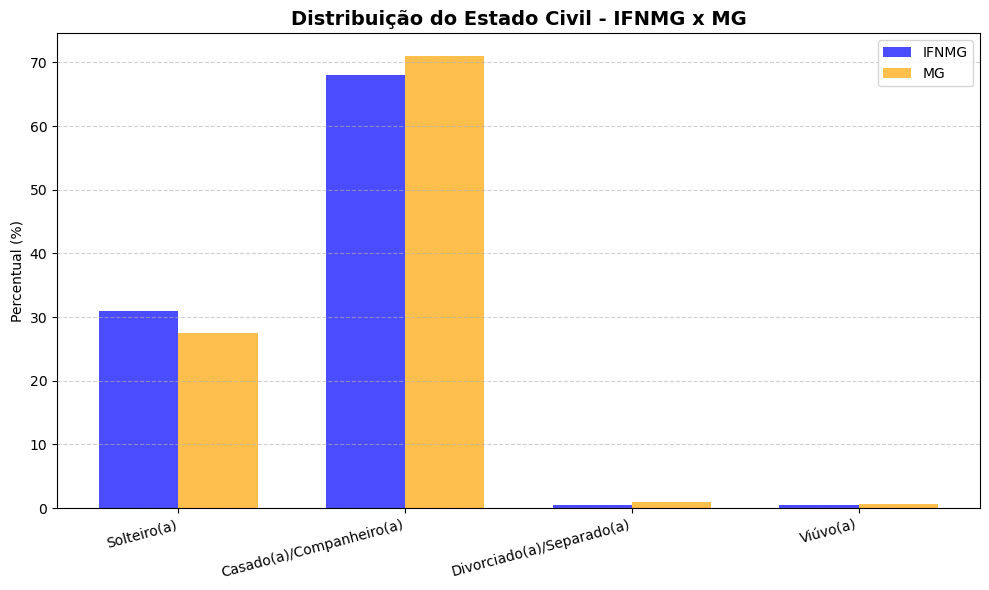

In [11]:
mapa_estado_civil = {
    0: "Solteiro(a)",
    1: "Casado(a)/Companheiro(a)",
    2: "Divorciado(a)/Separado(a)",
    3: "Viúvo(a)"
}

# Garantir tipo numérico (às vezes vem como string)
df_final["TP_ESTADO_CIVIL"] = pd.to_numeric(df_final["TP_ESTADO_CIVIL"], errors="coerce")
df_mg["TP_ESTADO_CIVIL"] = pd.to_numeric(df_mg["TP_ESTADO_CIVIL"], errors="coerce")

# ========== IFNMG ==========
df_final["TP_ESTADO_CIVIL_MAP"] = df_final["TP_ESTADO_CIVIL"].map(mapa_estado_civil)
qtd_ifnmg = df_final["TP_ESTADO_CIVIL_MAP"].value_counts().reindex(mapa_estado_civil.values(), fill_value=0)
pct_ifnmg = (qtd_ifnmg / qtd_ifnmg.sum() * 100).round(2)

# ========== MG ==========
df_mg["TP_ESTADO_CIVIL_MAP"] = df_mg["TP_ESTADO_CIVIL"].map(mapa_estado_civil)
qtd_mg = df_mg["TP_ESTADO_CIVIL_MAP"].value_counts().reindex(mapa_estado_civil.values(), fill_value=0)
pct_mg = (qtd_mg / qtd_mg.sum() * 100).round(2)

# ========== Tabela comparativa ==========
tabela = pd.DataFrame({
    "Qtd IFNMG": qtd_ifnmg,
    "% IFNMG": pct_ifnmg,
    "Qtd MG": qtd_mg,
    "% MG": pct_mg
}).fillna(0)

display(tabela)

# ========== Visualização (gráfico de barras lado a lado) ==========
plt.figure(figsize=(10,6))
largura = 0.35
categorias = tabela.index
x = range(len(categorias))

plt.bar([i - largura/2 for i in x], tabela["% IFNMG"], width=largura, label="IFNMG", color="blue", alpha=0.7)
plt.bar([i + largura/2 for i in x], tabela["% MG"], width=largura, label="MG", color="orange", alpha=0.7)

plt.xticks(x, categorias, rotation=15, ha="right")
plt.ylabel("Percentual (%)")
plt.title("Distribuição do Estado Civil - IFNMG x MG", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()



### **5. Quantidade de ocorrências por cada item - IFNMG**

In [9]:
variaveis = [
    "TP_SEXO", "TP_ESTADO_CIVIL", "TP_COR_RACA", "TP_NACIONALIDADE",
    "TP_ESCOLA", "TP_ENSINO","TP_LOCALIZACAO_ESC", "TP_SIT_FUNC_ESC",
    "TP_PRESENCA_CN", "TP_PRESENCA_CH", "TP_PRESENCA_LC", "TP_PRESENCA_MT",
    "TP_LINGUA", "TP_STATUS_REDACAO","EMP_DOMESTICO", "BANHEIRO", 
    "QTD_QUARTOS", "CARRO", "MOTO","GELADEIRA", "FREEZER", 
    "LAVA_ROUPA", "SECA_ROUPA", "MICROONDAS","LAVA_LOUCA", 
    "ASPIRADOR", "TV", "DVD", "TV_ASSINATURA",
    "CELULAR", "TELEFONE_FIXO", "COMPUTADOR", "INTERNET"
]

for col in variaveis:
    print("\n" + "="*60)
    print(f"📌 Variável: {col}")
    
    tabela = pd.crosstab(df_final["NU_ANO"], df_final[col], dropna=False)
    print(tabela)



📌 Variável: TP_SEXO
TP_SEXO      F     M
NU_ANO              
2018     11107  6786
2019      9300  5656
2020      3750  2589
2021      3925  2739
2022      4186  2942
2023      3935  2839

📌 Variável: TP_ESTADO_CIVIL
TP_ESTADO_CIVIL    0.0    1.0  2.0  3.0  4.0  NaN
NU_ANO                                           
2018             17405    177   14    5    0  292
2019               359  14369  156   70    2    0
2020               131   6142   22   43    1    0
2021               129   6457   34   43    1    0
2022               173   6888   29   37    1    0
2023               233   6457   37   47    0    0

📌 Variável: TP_COR_RACA
TP_COR_RACA    0     1     2      3    4    5
NU_ANO                                       
2018         258  3518  2657  10862  485  113
2019         203  2844  2233   9222  348  106
2020         117  1647   742   3646  153   34
2021         112  1983   835   3590  128   16
2022         115  2024   836   3995  132   26
2023          72  2144   808   3635

## **6. Gráfico da quantidade de participantes por ano do IFNMG.**

   NU_ANO  Participantes_IFNMG
0    2018                17893
1    2019                14956
2    2020                 6339
3    2021                 6664
4    2022                 7128
5    2023                 6774


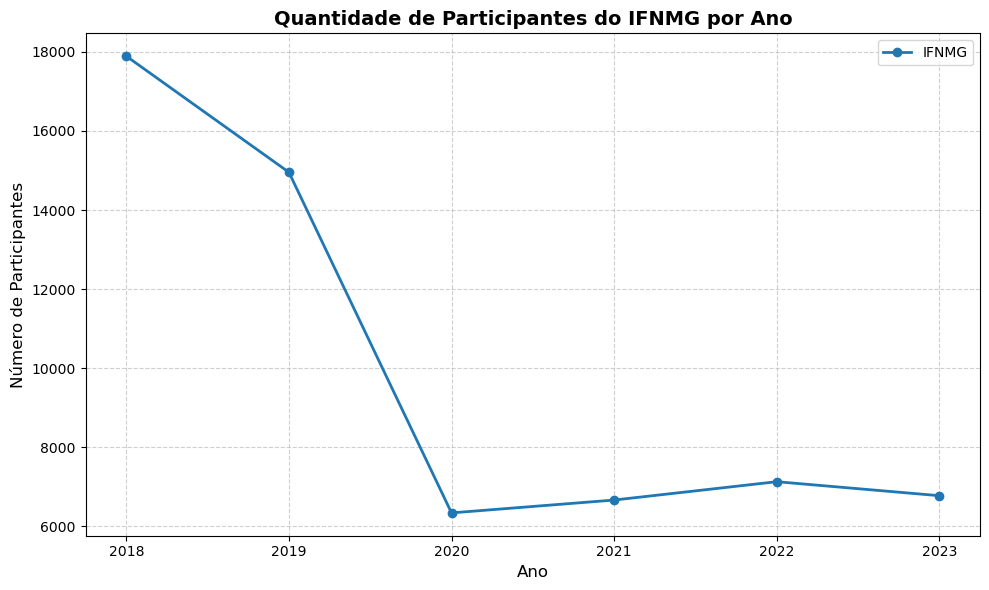

In [13]:
import matplotlib.pyplot as plt

# Agrupar por ano — IFNMG
qtd_ifnmg = df_final.groupby("NU_ANO").size().reset_index(name="Participantes_IFNMG")

print(qtd_ifnmg)

# ---------- GRÁFICO ----------
plt.figure(figsize=(10,6))

plt.plot(
    qtd_ifnmg["NU_ANO"],
    qtd_ifnmg["Participantes_IFNMG"],
    marker='o',
    linewidth=2,
    label="IFNMG"
)

plt.title("Quantidade de Participantes do IFNMG por Ano", fontsize=14, fontweight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Participantes", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


### **7. Comparativo entre as escolas do IFNMG**

In [10]:
import pandas as pd

# ============================================================
# 1️⃣ Função de padronização por ano
# ============================================================

def padronizar_tp_escola(row):
    ano = row["NU_ANO"]
    valor = row["TP_ESCOLA"]

    if pd.isna(valor):
        return "Não Informado"

    # 2018
    if ano == 2018:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            4: "Privada",
            3: "Exterior"
        }

    # 2019 e 2020
    elif ano in [2019, 2020]:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            3: "Privada",
            4: "Exterior"
        }

    # 2021+
    elif ano in [2021, 2022, 2023]:
        mapa = {
            1: "Não Informado",
            2: "Pública",
            3: "Privada"
        }

    else:
        return "Não Informado"

    return mapa.get(valor, "Não Informado")


# ============================================================
# 2️⃣ Criar nova variável (não sobrescreve a original)
# ============================================================

df_final["TP_ESCOLA_PAD"] = df_final.apply(padronizar_tp_escola, axis=1)


# Ordem fixa das categorias
ordem = ["Não Informado", "Pública", "Privada", "Exterior"]


# ============================================================
# 3️⃣ Quantidade e porcentagem
# ============================================================

qtd_ifnmg = (
    df_final["TP_ESCOLA_PAD"]
    .value_counts()
    .reindex(ordem, fill_value=0)
)

porc_ifnmg = (qtd_ifnmg / qtd_ifnmg.sum() * 100).round(2)


# ============================================================
# 4️⃣ Tabela final
# ============================================================

tabela_escola_ifnmg = pd.DataFrame({
    "Quantidade": qtd_ifnmg,
    "Percentual (%)": porc_ifnmg
})

display(tabela_escola_ifnmg)


,Quantidade,Percentual (%)
TP_ESCOLA_PAD,,
Não Informado,736,1.23
Pública,52538,87.92
Privada,6466,10.82
Exterior,14,0.02


## **Quantidade de Participantes do IFNMG por Raça/Cor e Ano**

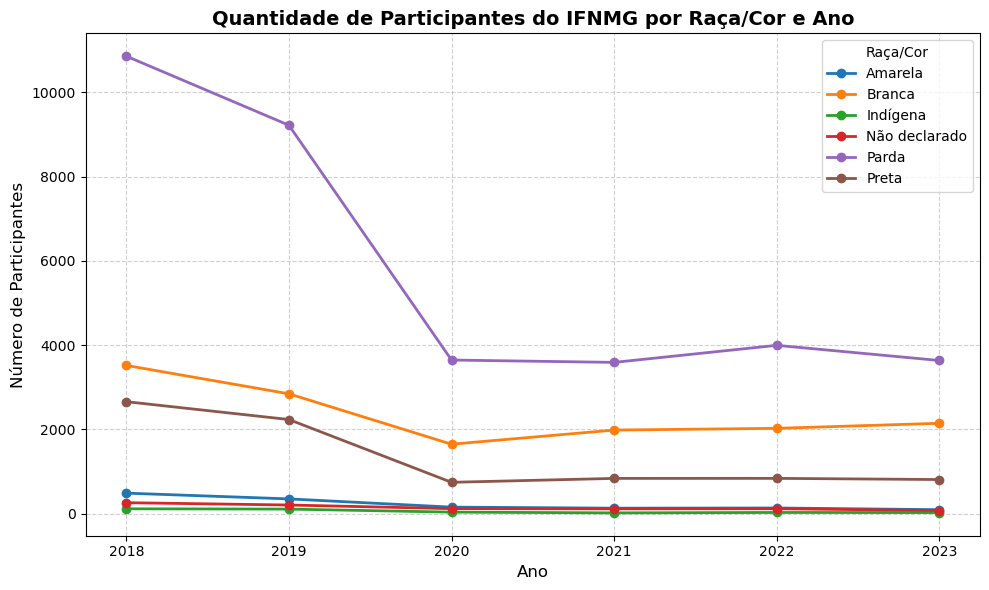

In [12]:
import matplotlib.pyplot as plt

# ================== MAPA DE RAÇA/COR ==================
mapa_raca = {
    0: "Não declarado",
    1: "Branca",
    2: "Preta",
    3: "Parda",
    4: "Amarela",
    5: "Indígena"
}

# Aplicar o mapeamento
df_final["TP_COR_RACA"] = df_final["TP_COR_RACA"].map(mapa_raca)

# ================== AGRUPAMENTO POR ANO E RAÇA ==================
qtd_raca_ano = (
    df_final
    .groupby(["NU_ANO", "TP_COR_RACA"])
    .size()
    .reset_index(name="Quantidade")
)

# ================== TRANSFORMAR EM FORMATO LARGO ==================
qtd_raca_pivot = qtd_raca_ano.pivot(
    index="NU_ANO",
    columns="TP_COR_RACA",
    values="Quantidade"
).fillna(0)

# ================== GRÁFICO ==================
plt.figure(figsize=(10, 6))

for raca in qtd_raca_pivot.columns:
    plt.plot(
        qtd_raca_pivot.index,
        qtd_raca_pivot[raca],
        marker='o',
        linewidth=2,
        label=raca
    )

plt.title("Quantidade de Participantes do IFNMG por Raça/Cor e Ano", fontsize=14, fontweight='bold')
plt.xlabel("Ano", fontsize=12)
plt.ylabel("Número de Participantes", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Raça/Cor")
plt.tight_layout()
plt.show()

In [14]:
import pandas as pd

# ================== MAPA DE RENDA (ENEM -> GRUPOS) ==================
mapa_renda = {
    "A": "Nenhuma",
    "B": "Até 1 Salário Mínimo",
    "C": "Entre 1 e 2",
    "D": "Entre 1 e 2",
    "E": "Entre 2 e 3",
    "F": "Entre 2 e 3",
    "G": "Entre 3 e 4",
    "H": "Entre 4 e 5",
    "I": "Acima de 5",
    "J": "Acima de 5",
    "K": "Acima de 5",
    "L": "Acima de 5",
    "M": "Acima de 5",
    "N": "Acima de 5",
    "O": "Acima de 5",
    "P": "Acima de 5",
    "Q": "Acima de 5"
}

# ================== APLICAR MAPEAMENTO ==================
df_final["RENDA_AGRUPADA"] = (
    df_final["RENDA_MENSAL"]
    .astype(str)
    .str.strip()
    .map(mapa_renda)
    .fillna("Não informado")
)

# ================== AGRUPAR ==================
tabela_renda = (
    df_final
    .groupby("RENDA_AGRUPADA")
    .size()
    .reset_index(name="Quantidade")
)

# ================== ORDENAR (PADRÃO TCC) ==================
ordem = [
    "Nenhuma",
    "Até 1 Salário Mínimo",
    "Entre 1 e 2",
    "Entre 2 e 3",
    "Entre 3 e 4",
    "Entre 4 e 5",
    "Acima de 5"
]

tabela_renda["RENDA_AGRUPADA"] = pd.Categorical(
    tabela_renda["RENDA_AGRUPADA"],
    categories=ordem,
    ordered=True
)

tabela_renda = tabela_renda.sort_values("RENDA_AGRUPADA")

# ================== RESULTADO FINAL ==================
tabela_renda

,RENDA_AGRUPADA,Quantidade
6,Nenhuma,3221
1,Até 1 Salário Mínimo,19404
2,Entre 1 e 2,18522
3,Entre 2 e 3,7079
4,Entre 3 e 4,3475
5,Entre 4 e 5,2296
0,Acima de 5,5741
7,NaN,16
